In [55]:
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [29]:
#Loading the dataset
df = pd.read_csv('/content/Housing.csv')

In [30]:
#displaying the first 5 rows of the dataset
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [31]:
#shape of the dataset
df.shape

(545, 13)

In [32]:
#descriptive statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [33]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [34]:
#columns name
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [35]:
#checking for missing values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [36]:
#Seperate numerical and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'prefarea', 'furnishingstatus'],
      dtype='object')

Categorical Features:
Index([], dtype='object')


In [37]:
# Grouping the columns for encoding
binary_cols   = ['mainroad', 'guestroom', 'basement',
                 'hotwaterheating', 'airconditioning', 'prefarea']

ordinal_cols  = ['furnishingstatus']

numeric_cols  = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

In [38]:
#defining the order for furnished status so it can be encoded in the following sequence
ordinal_enc = OrdinalEncoder(
    categories=[['unfurnished', 'semi-furnished', 'furnished']]
)


In [39]:
# Build ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('onehot',   OneHotEncoder(drop='if_binary'), binary_cols),
    ('ordinal',  ordinal_enc,                     ordinal_cols),
    ('scaler',   StandardScaler(),                numeric_cols)
])

In [40]:
# Features and Target
features = numeric_cols + binary_cols + ordinal_cols
X = df[features]
y = df['price']


In [41]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

In [58]:
#using linear regression
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
linear_model_pred = linear_model.predict(X_test_processed)

In [60]:
#evaluation function
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n {model_name}")
    print(f"   MAE      : {mae:,.0f}")
    print(f"   RMSE     : {rmse:,.0f}")
    print(f"   R² Score : {r2:.4f}")
    return mae, rmse, r2

In [61]:
#evaluation values
lr_mae,  lr_rmse,  lr_r2  = evaluate(y_test, linear_model_pred,  "Linear Regression")


 Linear Regression
   MAE      : 979,680
   RMSE     : 1,331,071
   R² Score : 0.6495


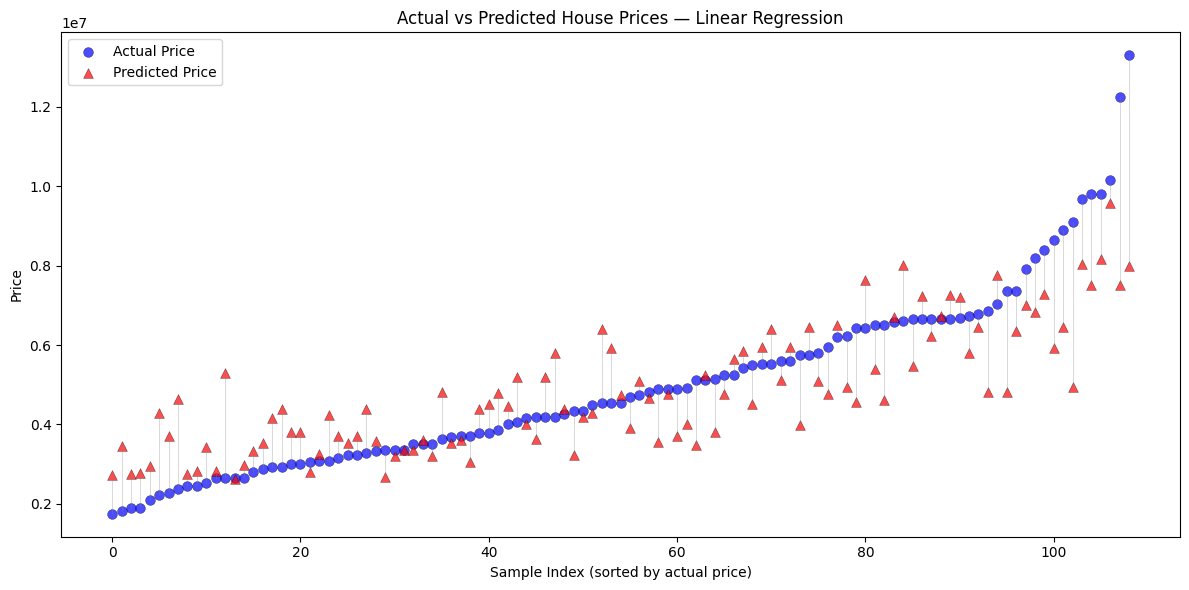

In [70]:
sorted_idx     = np.argsort(y_test.values)
actual_sorted  = np.array(y_test)[sorted_idx]
pred_sorted    = linear_model_pred[sorted_idx]
x_axis         = np.arange(len(actual_sorted))

plt.figure(figsize=(12, 6))

# Plot actual points
plt.scatter(x_axis, actual_sorted, color='blue', alpha=0.7,
            label='Actual Price', s=50, edgecolors='k', linewidths=0.3)

# Plot predicted points
plt.scatter(x_axis, pred_sorted, color='red', alpha=0.7,
            label='Predicted Price', s=50, marker='^',
            edgecolors='k', linewidths=0.3)

# Optional: connect actual and predicted with vertical lines to show error
for i in range(len(x_axis)):
    plt.plot([x_axis[i], x_axis[i]],
             [actual_sorted[i], pred_sorted[i]],
             color='gray', alpha=0.3, linewidth=0.7)

plt.title('Actual vs Predicted House Prices — Linear Regression')
plt.xlabel('Sample Index (sorted by actual price)')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.savefig('lr_actual_vs_predicted.png', dpi=120)
plt.show()